# Laboratory 5: Control What Images to Generate in Diffusion Models

This laboratory covers:

* Creating and training a conditional diffusion model to generate images we want
* Building a denoising U-Net from scratch
* Coding diffusion processes in a Denoising Diffusion Probabilistic Model (DDPM)
* Injecting labeling information and time steps into the U-Net model
* The idea of classifier-free guidance in training conditional and unconditional diffusion models simultaneously

In the previous laboratory, we learned how to create a diffusion model from scratch to generate images of clothing items such as coats, bags, and sandals. There are ten different types of clothing items and the model randomly generates images from one of these ten types. We may be wondering, can we tell the model to generate the item we want, such as a sandal, a t-shirt, or a coat? It turns out we can.

In this laboratory, we will learn to create and train a diffusion model to take in the label of a clothing item as the conditioning information so that the model generates the image we want. This skill has far-reaching implications in later laboratories. The goal of text-to-image generation is to create images based on text prompts. This requires the diffusion model to effectively incorporate the text description as the conditioning information and generate images that match this description. In this laboratory, we will explore the mechanisms that allow a diffusion model to integrate this information, ensuring that the generated images accurately reflect the given conditioning label.

In the previous laboratory, we treated the U-Net denoising model as a black box, relying on an out-of-the-box model from the `diffusers` library. This approach, while convenient, offers limited insight into the underlying workings of the model. In this laboratory, we will peel back the layers of abstraction by constructing a denoising U-Net model from scratch. This hands-on approach gives us a chance to understand the structure of the model, particularly how to incorporate class labels and time step information through embedding.

Moreover, we will create from scratch a Denoising Diffusion Probabilistic Model (DDPM), which forms the backbone of our diffusion process. We will code both the forward diffusion and reverse diffusion processes, learning how noise is gradually added and then removed to generate coherent images.

Classifier-free guidance is a very important concept in text-to-image generation. In a 2022 paper, J. Ho and T. Salimans show that guidance can be performed by a pure generative model without a classifier. They jointly train a conditional and unconditional diffusion model to attain a trade-off between sample quality and diversity. As we will see later, classifier-free guidance is a technique used to improve the quality of generated images in diffusion models. Traditional diffusion models use classifiers to guide the generation process. In contrast, classifier-free guidance bypasses the need for an external classifier by incorporating guidance within the model. The idea is to train the diffusion model both with and without conditioning information (class labels in this laboratory; text prompts in later laboratories). During training, sometimes the model is conditioned, and sometimes it is not. At inference time, guidance can be applied by interpolating between the conditional and unconditional predictions, allowing more controlled and more diverse image generation.

By the end of this laboratory, we will know how to create a fully functional conditional diffusion model from scratch. This knowledge will guide us in our exploration of more complex text-to-image generation models in subsequent laboratories.

# 1.	Different Components of a Denoising U-Net Model

In the next section, we will learn to create a denoising U-Net model from scratch. However,
before we implement the U-Net, we will provide a high-level overview of the
structure of the model and its components. We will learn how convolutional and max
pooling layers can extract feature maps from images and downsample these images.
We will also learn how transposed convolutional layers upsample and reconstruct feature
maps in images.

Furthermore, we will learn how to incorporate labeling and time step information
and then embed them in the U-Net model so that the U-Net model can denoise conditional
on both the time step and the label of the clothing item.

## 1.1.	Time Step Embedding and Label Embedding

When we train the denoising U-Net, we add noise to clean images in the training set to
create noisy images. We then present the noisy images, along with the time steps the
noisy images are in and the class labels of the images, to the U-Net. We train the U-Net
to predict the noise in the noisy images, conditional on the class labels.

We will embed the time steps and the labels when creating the U-Net so that it can
effectively understand these pieces of information when predicting the noise in the
noisy images. The figure below illustrates how to embed time steps and the class labels of the
clothing-item images in several embedding blocks of the U-Net model. The parameters
in these embedding blocks are first randomly initialized and then adjusted during
training. The figure shows that we use a noise schedule to generate a noisy image of a
clean pullover image from the training set. In this case, the time step is $25$, and the class
label is $2$ (any other time step or class label will work; here we use $25$ and $2$ as concrete
examples). We generate two time embeddings for later use, with dimensions $(512, 1, 1)$ and $(256, 1, 1)$, respectively. Similarly, we use embedding blocks in the U-Net model
to create two label embeddings with dimensions $(512, 1, 1)$ and $(256, 1, 1)$, respectively.
The time embeddings and label embeddings will be used in the expansive path
(i.e., decoder) of the U-Net.

We define the following embedding block to embed both time steps and the labeling information:

In [ ]:
from torch import nn
class EmbedLayer(nn.Module):
    def __init__(self, input_dim, emb_dim):    #The input and embedding dimensions are input_dim and emb_dim, respectively
        super().__init__()
        self.input_dim = input_dim
        layers = [nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),]    #The input goes through the two linear layers, with a GELU activation in between
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [ ]:
import torch

timeembed1=EmbedLayer(1, 512)    #Instantiates two time embedding blocks, with embedding dimensions 512 and 256
timeembed2=EmbedLayer(1, 256)

timesteps=torch.tensor([25]).long()    #Uses the relative time step as the input
t=timesteps/1000
temb1 = timeembed1(t).view(-1, 512, 1, 1)
temb2 = timeembed2(t).view(-1, 256, 1, 1)
print("the shape of the first time embedding is", temb1.shape)    #Prints out the shape of the two time embeddings
print("the shape of the second time embedding is", temb2.shape)

the shape of the first time embedding is torch.Size([1, 512, 1, 1])
the shape of the second time embedding is torch.Size([1, 256, 1, 1])


The shape of the first time embedding is $(1, 512, 1, 1)$. The first value in $(1, 512, 1, 1)$
means there’s one sample in the batch. The last three values in $(1, 512, 1, 1)$ indicate
that the time step is converted into an embedding tensor with a shape of $(512, 1, 1)$.
The shape of the second time embedding is $(1, 256, 1, 1)$, meaning the time step is
converted into an embedding tensor with a shape of $(256, 1, 1)$.

To embed the labeling information, we first convert the label, which can take a value
between $0$ and $9$, into a $10$-value one-hot tensor. We mask the labeling information
with a $10\%$ probability so that we train an unconditional model with a $10\%$ probability
and a conditional model with a $90\%$ probability. We will instantiate two label embedding
blocks and pass the one-hot label tensor through the embedding blocks to obtain the
label embeddings, as shown in the following:

In [ ]:
n_classes=10
contextembed1=EmbedLayer(n_classes, 512)    #Instantiates two label embedding blocks
contextembed2=EmbedLayer(n_classes, 256)
label=torch.tensor([2, 9, 0]).long()    #Creates a batch of three labels
context_mask = torch.bernoulli(
    torch.zeros_like(label)+0.1)    #Generates a mask to hide the label with a 10% probability
onehot = torch.nn.functional.one_hot(label,
            num_classes=n_classes).type(torch.float)    #Converts each label to a one-hot tensor with ten values
context_mask = context_mask[:, None]
context_mask = context_mask.repeat(1,n_classes)
context_mask = (-1*(1-context_mask))
c = onehot * context_mask
cemb1 = contextembed1(c).view(-1, 512, 1, 1)
cemb2 = contextembed2(c).view(-1, 256, 1, 1)
print("the shape of the first label embedding is", cemb1.shape)
print("the shape of the second label embedding is", cemb2.shape)

the shape of the first label embedding is torch.Size([3, 512, 1, 1])
the shape of the second label embedding is torch.Size([3, 256, 1, 1])


Instead of using just one noisy image in the batch, we assume there are three images,
so we put three values—$2, 9,$ and $0$—in the label tensor in the preceding code.
Further, we convert the labels into $10$-value one-hot tensors because there are $10$ different
types of clothing items in the training dataset. We instantiate two label embedding
blocks, with an input dimension of $10$ (because labels are represented by $10$-value one-hot
tensors now) and embedding dimensions of $512$ and $256$, respectively. Masking
the labeling information is our way of implementing classifier-free guidance (CFG).
This way, we train an unconditional model and a conditional model simultaneously.

The shapes of the two label embeddings are $(3, 512, 1, 1)$ and $(3, 256, 1, 1)$, respectively.
The first number in the shape, $3$, means that there are three labels in the batch.
The last three values in the shape indicate that the labels are converted into embedding
tensors with a shape of $(512, 1, 1)$ by the first embedding block, and they are converted
into embedding tensors with a shape of $(256, 1, 1)$ by the second embedding block.

# 2.    Building and Training the Denoising U-Net Model from Scratch
We will learn to create a denoising U-Net model from scratch in this section. Along the
way, we will implement label embedding and time embedding so that the U-Net model
can denoise conditional on both time steps and the label of the clothing item. We will
also discuss how to code the CFG and how to choose the strength of the generative
guidance.

We will build a Denoising Diffusion Probabilistic Model (DDPM) from scratch. We will
use the Fashion MNIST dataset to train the model. Specifically, we will use the noise
scheduler in DDPM to add noise to clean images in the training dataset to create noisy
images. The U-Net model is used to predict the noise in the noisy images. We use the
DDPM to calculate the mean squared error between the actual noise and the predicted
noise. We adjust model parameters to minimize this error.

## 2.1. Building the denoising U-Net


The contracting path of the U-Net consists of multiple down blocks. We define down blocks in the `UnetDown` class:

In [ ]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_res = False):
        super().__init__()
        self.same_channels = in_channels==out_channels
        self.is_res = is_res
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),)
    def forward(self, x):
        if self.is_res:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            if self.same_channels:
                out = x + x2
            else:
                out = x1 + x2
            return out / 1.414
        else:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            return x2

In [ ]:
class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [ResidualConvBlock(in_channels,
                out_channels), nn.MaxPool2d(2)] #The down block consists of a residual convolutional block and a 2D max pooling layer
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

The down block uses the 2D max pooling layer to reduce the size of the input by half in
both image width and image height. Specifically, the `nn.MaxPool2d(2)` layer in PyTorch
selects the maximum pixel value in a $2 × 2$ window.
Each down block also uses residual convolutional blocks, which are defined in the
`ResidualConvBlock` class, defined above.

The expansive path of the U-Net consists of multiple up blocks. We define the `UnetUp` class to construct an up block:

In [ ]:
class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_channels,
                                     out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),] #The up block consists of two residual convolutional blocks and a 2D transposed convolutional layer
        self.model = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

The up block uses the 2D transposed convolutional layer to upsample features in the
input. Transposed convolutional layers fill in gaps
in an image to generate features and increase resolution. The output is usually larger
than the input in a transposed convolutional layer.

We define a `UNet` class that can be either a conditional denoising
model or an unconditional denoising model. A *conditional denoising model* generates
a clothing-item image of a particular class, say, class $4$ (a coat) or class $2$ (a pullover). In
contrast, an *unconditional denoising model* randomly generates a clothing-item image that
belongs to any of the $10$ classes. Part of the `UNet` class is shown in the following code:

In [ ]:
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat = 256, n_classes=10):
        super().__init__()
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_classes = n_classes
        self.init_conv = ResidualConvBlock(in_channels,
                               n_feat, is_res=True)
        self.down1 = UnetDown(n_feat, n_feat)
        self.down2 = UnetDown(n_feat, 2 * n_feat)
        self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.timeembed1 = EmbedLayer(1, 2*n_feat)
        self.timeembed2 = EmbedLayer(1, 1*n_feat)
        self.contextembed1 = EmbedLayer(n_classes, 2*n_feat)
        self.contextembed2 = EmbedLayer(n_classes, 1*n_feat)
        self.up0=nn.Sequential(nn.ConvTranspose2d(2*n_feat,2*n_feat,7,7),
            nn.GroupNorm(8, 2 * n_feat),nn.ReLU(),)
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)
        self.out = nn.Sequential(nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1),)
    def forward(self, x, c, t, context_mask):
        x = self.init_conv(x)
        down1 = self.down1(x)
        down2 = self.down2(down1)
        hiddenvec = self.to_vec(down2) #The input images first go through multiple down blocks and then the bottleneck
        c=nn.functional.one_hot(c,num_classes=self.n_classes).type(torch.float)
        context_mask = context_mask[:, None]
        context_mask = context_mask.repeat(1,self.n_classes)
        context_mask = (-1*(1-context_mask))
        c = c * context_mask #The labels are masked with a 10% probability, so the model acts both as an unconditional model and a conditional model
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1) #Label and time embeddings are used in up blocks
        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1+ temb1, down2)
        up3 = self.up2(cemb2*up2+ temb2, down1) #Skip connections are used to merge features from contracting and expansive paths
        out = self.out(torch.cat((up3, x), 1))
        return out

The `UNet` class takes noisy images, `x`, labels, `c`, and time steps, `t`, as inputs to predict
the noise in the images. It also takes `context_mask` as an argument. If we set `context_mask` to `1`, the labeling information is masked, and the model is therefore an unconditional
model. On the other hand, if `context_mask=0`, the labeling information is used,
and the generation is conditional on the label. Later, when training the model, we will
set `context_mask` to `1` with a $10\%$ probability to train an unconditional model. In the
remaining $90\%$ of the time, `context_mask=0`, and we train a conditional model.

The input image first goes through multiple down blocks and then the bottleneck
block. The output from the bottleneck goes through multiple up blocks. We create two
label embeddings and two time embeddings to be used in the two up blocks. In addition,
skip connections are used to merge corresponding features from the contracting
and expansive path.

## 2.2. The Denoising Diffusion Probabilistic Model (DDPM)

Now that we have a denoising U-Net model, we will add noise to clean images to generate
noisy images. These noisy images are then used to train the denoising U-Net model. We define the following `DDPM` class to create the DDPM.

In [ ]:
def noise_scheduler(T):
    beta1, beta2 = 0.0001, 0.02
    beta_t = (beta2 - beta1) * torch.arange(0, T + 1,
                    dtype=torch.float32) / T + beta1
    sqrt_beta_t = torch.sqrt(beta_t)
    alpha_t = 1 - beta_t
    log_alpha_t = torch.log(alpha_t)
    alphabar_t = torch.cumsum(log_alpha_t, dim=0).exp()
    sqrtab = torch.sqrt(alphabar_t)
    oneover_sqrta = 1 / torch.sqrt(alpha_t)
    sqrtmab = torch.sqrt(1 - alphabar_t)
    mab_over_sqrtmab_inv = (1 - alpha_t) / sqrtmab
    return {"alpha_t": alpha_t,  # \alpha_t
        "oneover_sqrta": oneover_sqrta,  # 1/\sqrt{\alpha_t}
        "sqrt_beta_t": sqrt_beta_t,  # \sqrt{\beta_t}
        "alphabar_t": alphabar_t,  # \bar{\alpha_t}
        "sqrtab": sqrtab,  # \sqrt{\bar{\alpha_t}}
        "sqrtmab": sqrtmab,  # \sqrt{1-\bar{\alpha_t}}
        # (1-\alpha_t)/\sqrt{1-\bar{\alpha_t}}
        "mab_over_sqrtmab": mab_over_sqrtmab_inv,}

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
class DDPM(nn.Module):
    def __init__(self, model, n_T, device=device, drop_prob=0.1):
        super().__init__()
        self.model = model.to(device)
        for k, v in noise_scheduler(n_T).items():
            self.register_buffer(k, v)
        self.n_T = n_T
        self.device = device
        self.drop_prob = drop_prob
        self.loss_mse = nn.MSELoss()
    def forward(self, x, c):
        _ts=torch.randint(1,self.n_T+1,(x.shape[0],)).to(self.device) #Randomly generates time steps between 1 and 1,000
        noise = torch.randn_like(x)
        x_t = (self.sqrtab[_ts, None, None, None] * x
            + self.sqrtmab[_ts, None, None, None] * noise) #Generates noisy images as the weighted sum of clean images and noise
        context_mask = torch.bernoulli(torch.zeros_like(c)+
                                   self.drop_prob).to(self.device)
        return self.loss_mse(noise,
                 self.model(x_t, c, _ts / self.n_T, context_mask)) #The output is the mean squared error between the actual noise and the predicted noise

The `DDPM` class takes in two arguments, `x` and `c`, where `x` is a batch of clean images,
and `c` is a tensor with the corresponding class labels. The `DDPM` class randomly generates
a time step for each image and injects noise into these images. We then train
the U-Net denoising model we created earlier to predict the noise in the noisy images.
The `DDPM` class returns the mean squared error between the predicted noise and the
ground truth (the actual noise injected into the images). We also define a `sample()`
function to generate images using the trained model.

In [ ]:
import numpy as np

@torch.no_grad()
def sample(ddpm, model, n_sample, size, device,
           guide_w = 0.0, step_size=1):
    x_i = torch.randn(n_sample, *size).to(device)
    c_i = torch.arange(0,10).to(device) #The class labels have values 0 to 9, so we generate 10 different types of images
    c_i = c_i.repeat(int(n_sample/c_i.shape[0]))
    context_mask = torch.zeros_like(c_i).to(device)
    c_i = c_i.repeat(2)
    context_mask = context_mask.repeat(2)
    context_mask[n_sample:] = 1. #The first half of the mask is turned off as 0s, and the second half is turned on as 1s
    x_i_store = []
    for i in range(ddpm.n_T, 0, -step_size):
        t_is = torch.tensor([i / ddpm.n_T]).to(device)
        t_is = t_is.repeat(n_sample,1,1,1)
        x_i = x_i.repeat(2,1,1,1)
        t_is = t_is.repeat(2,1,1,1)
        z = torch.randn(n_sample,*size).to(device) if i>1 else 0
        eps = model(x_i, c_i, t_is, context_mask)
        eps1 = eps[:n_sample] #Generates a set of images using the conditional model
        eps2 = eps[n_sample:] #Generates a set of images using the unconditional model
        eps = (1+guide_w)*eps1 - guide_w*eps2 #The final output is a weighted sum of conditional and unconditional generation
        x_i = x_i[:n_sample]
        x_i = (ddpm.oneover_sqrta[i] * (x_i -
                    eps * ddpm.mab_over_sqrtmab[i])
            + ddpm.sqrt_beta_t[i] * z)
        if i%20==0 or i==ddpm.n_T or i<8:
            x_i_store.append(x_i.detach().cpu().numpy())
    x_i_store = np.array(x_i_store)
    return x_i, x_i_store

The `sample()` function follows the guidance sampling scheme described in the
2022 paper by Ho and Salimans. We create class labels with values $0$ to $9$ so we
can generate all $10$ types of clothing-item images. Values in the first half of the tensor
`context_mask`
are turned off as $0$s, and we use them for conditional generation. That is,
clothing-item images are generated based on specific labels, ranging from $0$ to $9$. The
values in the second half of the tensor `context_mask` are turned on as $1$s. Therefore,
clothing labels are masked. Clothing-item images are generated unconditionally and
can be any of the $10$ types. The output is a mix of conditional and unconditional generation.
The parameter `guide_w` controls the strength of the label guidance in image
generation.

## 2.3. Training the Diffusion Model

Next, we will train the CFG diffusion model. We will first preprocess the training data and
then discuss the training loop. As in Laboratory 4, we use grayscale clothing-item images as our training data:

In [ ]:
from torchvision import transforms, datasets

torch.manual_seed(42)
tf = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Lambda(lambda x: 2*(x-0.5)),])    #Converts raw image data into PyTorch tensors with values between −1 and 1
dataset = datasets.FashionMNIST(
    r".",
    train=True,
    download=True,
    transform=tf,)    #Downloads the training dataset using the TorchVision library

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.24MB/s]


The `transforms` package in TorchVision creates a series of transformations to preprocess
images. The images have a size of $(1, 28, 28)$. The `ToTensor()` function converts image
data into PyTorch tensors, with values in the range of `0.0` and `1.0`. We normalize the
input data to the range `[-1.0, 1.0]` for faster convergence during training. We can
then use the `datasets` package in TorchVision to download the dataset to a folder and perform the transformation.

There are $10$ different types of clothing items. The labels in the dataset are numbered
from $0$ to $9$. The list `text_labels` contains the $10$ text labels corresponding to the
numerical labels $0$ to $9$:

In [ ]:
text_labels=['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

We put the training data in batches, as follows, and our training data is ready:

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

We create a denoising U-Net model by instantiating the `UNet` class we defined earlier.
We also create a DDPM by instantiating the `DDPM` class.

In [ ]:
n_epoch = 20
n_T = 1000
device="cuda" if torch.cuda.is_available() else "cpu"
n_classes = 10
n_feat = 256
lrate=0.00001
model=Unet(in_channels=1,
           n_feat=n_feat,
           n_classes=n_classes)    #Creates a U-Net model by instantiating the Unet class
ddpm=DDPM(model, n_T=n_T).to(device)    #Creates a DDPM to help train the U-Net model
optim = torch.optim.Adam(ddpm.parameters(), lr=lrate)

The objective of the U-Net model is to predict the noise in noisy images. It plays a
crucial role in the DDPM we just created. Specifically, the DDPM takes clean images
from the training set and adds noise to them to create noisy images. It then presents
the noisy images to the U-Net and asks it to predict the noise in the images. The DDPM
then calculates the mean squared error between the actual noise and the predicted
noise. We will train the model for $20$ epochs.

In [ ]:
#55 min
from tqdm import tqdm
scaler = torch.amp.GradScaler("cuda")
for ep in range(n_epoch):
    print(f'epoch {ep}')
    ddpm.train()
    optim.param_groups[0]["lr"]=lrate*(1-ep/n_epoch)
    pbar=tqdm(dataloader)
    loss_ema=None
    for x, c in pbar:    #Iterates through all batches of training data
        x = x.to(device)
        c = c.to(device)
        with torch.amp.autocast("cuda"):
            loss = ddpm(x,c)    #Uses the DDPM to calculate the error between the predicted noise and the actual noise
        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()
        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.95 * loss_ema + 0.05 * loss.item()
        pbar.set_description(f"loss: {loss_ema:.4f}")
        optim.step()    #Backpropagates to adjust model parameters
torch.save(model.state_dict(),"files/conditional.pth")    #Saves the trained model parameters

epoch 0


loss: 0.0860: 100%|██████████| 235/235 [02:41<00:00,  1.46it/s]


epoch 1


loss: 0.0676: 100%|██████████| 235/235 [02:47<00:00,  1.41it/s]


epoch 2


...

loss: 0.0463: 100%|██████████| 235/235 [02:47<00:00,  1.40it/s]


epoch 18


loss: 0.0432: 100%|██████████| 235/235 [02:46<00:00,  1.41it/s]


epoch 19


loss: 0.0457: 100%|██████████| 235/235 [02:47<00:00,  1.40it/s]


In each epoch, we iterate through all batches of training data `(x, c)`, where `x` is the
clean clothing-item images and `c` is the labels. The DDPM calculates the mean square
error between the actual noise and the noise predicted by the denoising U-Net model.
We adjust model parameters to minimize this error.

The above training takes less than an hour with GPU training. Alternatively, the trained model can be downloaded from Google Drive https://drive.google.com/file/d/1ar61VVWYK8XwvEoGdq-ZcBDgH9Ok35kA/view?usp=drive_link. Unzip the file after downloading and place it in the `files` folder.

# 3. Generating Images with the Trained Conditional Diffusion Model

In this section, we will generate images conditional on the labeling information using
the model we just trained. First, we will see how the trained model generates images
from random noise. We use $1,000$ reference steps, and we will see the generated image after every $200$ time steps.

Second, we will experiment with the generation guidance parameter `guide_w`. When
the value of `guide_w` is large, the generated images match the labels well but lack diversity.
When `guide_w` is small, you see more diversity, but the generated images may not
match the labels closely.

## 3.1. Visualize Generated Images in Different Time Steps

We will first load the trained model weights to the U-Net denoising model. We then generate
$10$ images, as shown in the following listing.

In [ ]:
model.load_state_dict(torch.load("files/conditional.pth",
            weights_only=True,
            map_location=device))    #Loads trained model parameters
x,c=next(iter(dataloader))
x,c=x.to(device),c.to(device)
ddpm.eval()
n_sample = n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
            device,guide_w=2)    #Generates 10 images using the trained model
x_real = torch.Tensor(x_gen.shape).to(device)    #Selects 10 real images for comparison
for k in range(n_classes):
    try:
        idx = torch.squeeze((c == k).nonzero())[0]
    except:
        idx = 0
    x_real[k] = x[idx]
x_all = torch.cat([x_gen, x_real])


The $10$ generated images are in the tensor `x_gen`, with labels $0$ to $9$. We then select $10$
clean images from the training set, with labels $0$ to $9$ as well. The real images are saved
in `x_real`. We concatenate the $20$ images in a tensor `x_all`. Next, we plot the generated
images along with the real images so that we can compare them, as in the following:

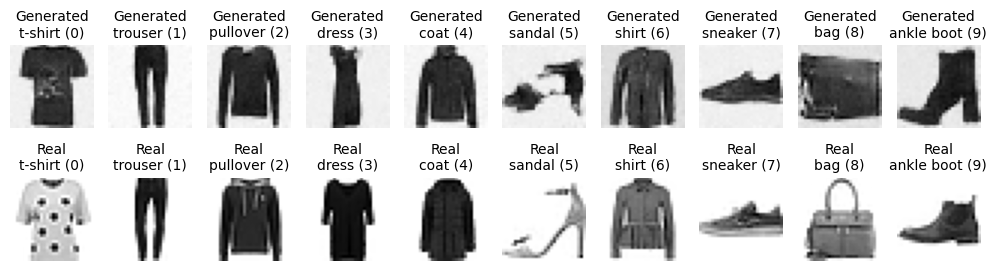

In [ ]:
captions=[]
for i in range(20):
    gen="Generated" if i<10 else "Real"
    num=i%10
    label_and_num=f"{gen}\n{text_labels[num]} ({num})"
    captions.append(label_and_num) #Creates a description for each image

from matplotlib import pyplot as plt

plt.figure(figsize=(10,3),dpi=100)
for i in range(20): #Plots the generated images on top and the real images at the bottom
    plt.subplot(2,10,i+1)
    plt.imshow(x_all[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    plt.title(captions[i],fontsize=10)
plt.tight_layout()
plt.show()

We plot the generated images along with the real images. We create a description for
each image, displaying whether it is generated or real, along with the text label and the
numerical label. We plot the images in a $2 × 10$ grid, with generated images in the top
row and real images at the bottom row. As we can see, the generated images match the
label, and they resemble the real images from the training set.

## 3.2. How the Guidance Parameter Affect the Generated Images

So far, we have set the guidance parameter `guide_w` to `2`. What happens if we set the value
to a different number, say, `5`? Let’s find out.

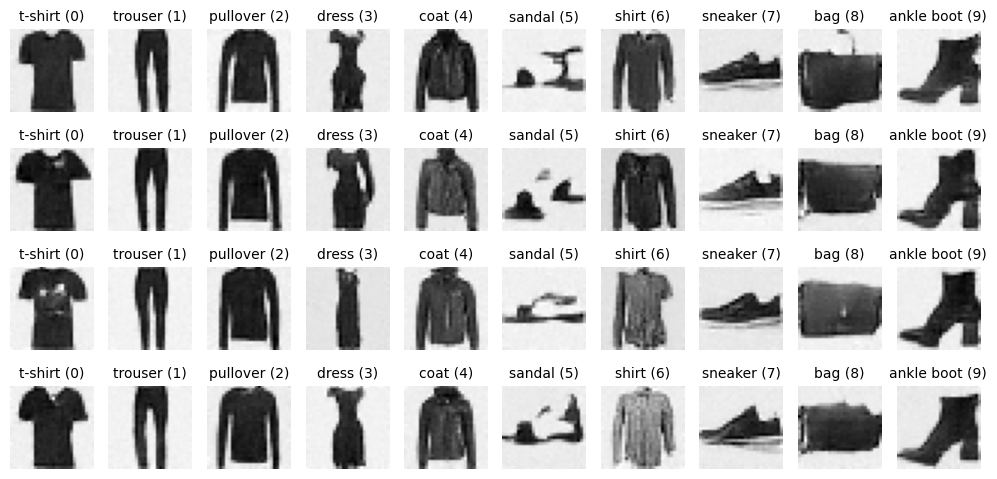

In [ ]:
#3 min
n_sample  = 4*n_classes
x_gen,x_gen_store=sample(ddpm,model,n_sample,(1,28,28),
                              device,guide_w=5)    #Generates 40 images by setting the guidance parameter to 5
plt.figure(figsize=(10,5),dpi=100)
for i in range(40):    #Plots the generated images in a 4 × 10 grid
    plt.subplot(4,10,i+1)
    plt.imshow(x_gen[i].cpu().permute(1,2,0)/2+0.5,
               cmap="binary")
    plt.axis('off')
    c=i%10
    plt.title(f"{text_labels[c]} ({c})",fontsize=10)
plt.tight_layout()
plt.show()


We generate $40$ images and plot them in a $4 × 10$ grid. The generated images match the
label closely. The first column displays t-shirts with labels $0$, the second column shows
trousers with labels $1$, and so on. The last column shows four ankle boots with label $9$.
The items match the labels fairly closely because the guidance parameter value is relatively
high (value of $5$).

So far, the images generated by our diffusion models have been grayscale. This simplification
is intentional, allowing us to focus on the core principles of how diffusion
models work. In the next laboratory, we will build a more advanced diffusion model
capable of generating high-resolution color images. Additionally, we will explore how
the initial noise tensor at time step $1,000$ influences the final output. By interpolating
between different noise tensors, we can create composite images that blend multiple
color images. This also allows us to generate images that smoothly transition from one
to another by adjusting the weights on the noise tensors.

# Exercises

1.   Suppose the time step value is $42$. Modify the code for creating the two time embeddings to create two time embeddings
with embedding dimensions $512$ and $256$, respectively. Then, print out the shape of
the two time embeddings.

2.   Suppose there are four labels in the batch with values $1, 3, 5,$ and $7$, respectively.
Modify the code for generating label embeddings to create two label embeddings. Then, print out the shape of the
two label embeddings.

3.   Generate $40$ images by setting the guidance parameter to $1$. Then, plot the generated
images in a $4 × 10$ grid.